$x = (x[0], \cdots, x[3])^\top = (1, 2, 0, 1)^\top$ と $h = (h[0], h[1], h[2])^\top = (1/3, 1/3, 1/3)^\top$ を考える．
1. 線形畳み込み $y = x * h$ を手計算しなさい．また，その結果得られる信号 $y$ の長さを求めなさい．
2. 4点巡回畳み込み $y_4 = x \circledast_4 h$ を手計算しなさい．また，その結果得られる信号 $y_4$ の長さを求めなさい．
3. numpy.convolve(x, h) を使って線形畳み込み $y = x * h$ を計算し， $y$ を stem プロットしなさい．
4. circular_convolve_direct(x, h, N=4) を使って巡回畳み込み $y_4 = x \circledast_4 h$ を計算し， $y_4$ を stem プロットしなさい．
5. $x$ の4点DFTと $h$ の4点DFTを計算し，それらの積の逆DFTを計算して，巡回畳み込み $y_4 = x \circledast_4 h$ の結果と比較しなさい．
6. circular_convolve_direct(x, h, N) の $N$ を変化させて巡回畳み込み $y_N = x \circledast_N h$ を計算し， $y_N$ が $y$ と一致するための $N$ の条件を考察しなさい．

1. $y[n]=(x*h)[n]=\sum_k x[k]h[n-k]$

\begin{align*}
y[0]&=1\cdot \frac13=\frac13\\
y[1]&=1\cdot \frac13+2\cdot \frac13=1\\
y[2]&=1\cdot \frac13+2\cdot \frac13+0\cdot \frac13=1\\
y[3]&=2\cdot \frac13+0\cdot \frac13+1\cdot \frac13=1\\
y[4]&=0\cdot \frac13+1\cdot \frac13=\frac13\\
y[5]&=1\cdot \frac13=\frac13
\end{align*}

2. 4点巡回畳み込み

\begin{align*}
y_4[0]&=y[0]+y[4]=\frac23,\qquad \\
y_4[1]&=y[1]+y[5]=\frac43,\qquad \\
y_4[2]&=y[2]=1,\qquad \\
y_4[3]&=y[3]=1
\end{align*}

したがって

\begin{align*}
y_4=\left(\frac23,\frac43,1,1\right)^\top
\end{align*}
長さは4

3. 

線形畳み込み y = [0.333333 1.       1.       1.       0.333333 0.333333]
長さ = 6


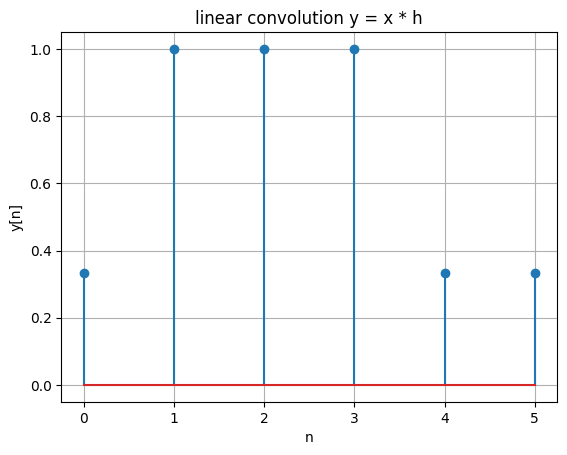

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


x = np.array([1, 2, 0, 1], dtype=float)
h = np.array([1/3, 1/3, 1/3], dtype=float)

y = np.convolve(x, h, mode="full")
print("線形畳み込み y =", y)
print("長さ =", len(y))

plt.figure()
plt.stem(np.arange(len(y)), y)
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("linear convolution y = x * h")
plt.grid(True)
plt.show()

4. 

4点巡回畳み込み y4 = [0.666667 1.333333 1.       1.      ]
長さ = 4


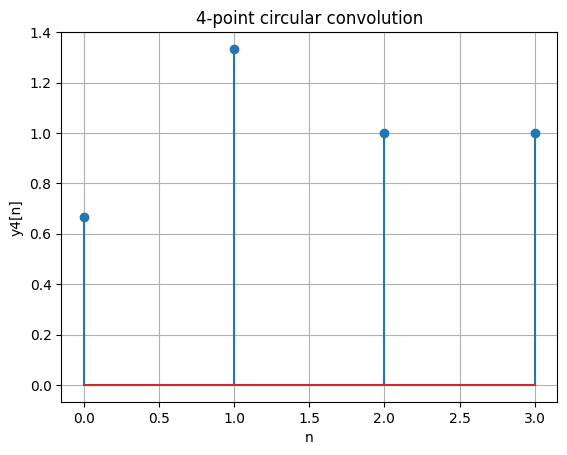

In [2]:
def periodize(x, N):
    x = np.asarray(x)
    y = np.zeros(N, dtype=x.dtype)
    np.add.at(y, np.arange(x.size) % N, x)
    return y

def circular_convolve_direct(x, h, N=None):
    x = np.asarray(x)
    h = np.asarray(h)

    if N is None:
        if x.size != h.size:
            raise ValueError("x と h の長さが異なる場合は N を指定してください．")
        N = x.size

    xN = periodize(x, N)
    hN = periodize(h, N)

    dtype = np.result_type(xN, hN, np.float64)
    y = np.zeros(N, dtype=dtype)

    for n in range(N):
        for k in range(N):
            y[n] += xN[k] * hN[(n-k) % N]
    return y

y4 = circular_convolve_direct(x, h, N=4)
print("4点巡回畳み込み y4 =", y4)
print("長さ =", len(y4))

plt.figure()
plt.stem(np.arange(len(y4)), y4)
plt.xlabel("n")
plt.ylabel("y4[n]")
plt.title("4-point circular convolution")
plt.grid(True)
plt.show()

5．DFTによる畳み込み定理の確認

4点巡回畳み込みは，4点DFTの積の逆DFTで求まります

\begin{align*}
y_4=\mathrm{IDFT}\{X[k]H[k]\}
\end{align*}

In [3]:
N = 4
X = np.fft.fft(x, n=N)
H = np.fft.fft(h, n=N)
Y = X * H
y4_fft = np.fft.ifft(Y)

print("X =", X)
print("H =", H)
print("X*H =", Y)
print("ifft(X*H) =", y4_fft)
print("circular_convolve_direct と一致するか =", np.allclose(y4_fft.real, y4))

X = [ 4.+0.j  1.-1.j -2.+0.j  1.+1.j]
H = [1.      +0.j       0.      -0.333333j 0.333333+0.j
 0.      +0.333333j]
X*H = [ 4.      +0.j       -0.333333-0.333333j -0.666667+0.j
 -0.333333+0.333333j]
ifft(X*H) = [0.666667+0.j 1.333333+0.j 1.      +0.j 1.      +0.j]
circular_convolve_direct と一致するか = True


6．巡回畳み込みが線形畳み込みと一致する条件

長さ $L_x$ と $L_h$ の線形畳み込みの長さは $L_x+L_h-1$ ．巡回畳み込みで折り返しが起こらないためには，$N$ がこの長さ以上である必要

\begin{align*}
N \ge L_x+L_h-1
\end{align*}

ここでは $L_x=4$，$L_h=3$ なので，

\begin{align*}
N\ge 6
\end{align*}

In [4]:
for N in range(3, 9):
    yN = circular_convolve_direct(x, h, N=N)
    print(f"N={N}: y_N={yN}")

print("\nN=6 以上では，線形畳み込みをゼロ詰めした結果と一致．")

N=3: y_N=[1.333333 1.333333 1.333333]
N=4: y_N=[0.666667 1.333333 1.       1.      ]
N=5: y_N=[0.666667 1.       1.       1.       0.333333]
N=6: y_N=[0.333333 1.       1.       1.       0.333333 0.333333]
N=7: y_N=[0.333333 1.       1.       1.       0.333333 0.333333 0.      ]
N=8: y_N=[0.333333 1.       1.       1.       0.333333 0.333333 0.       0.      ]

N=6 以上では，線形畳み込みをゼロ詰めした結果と一致．
